<a href="https://colab.research.google.com/github/ofredrickson/music_trends/blob/main/datascience_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd

df = pd.read_csv('spotifysongs.csv')
df.head()

,id,name,artists,duration_ms,release_date,year,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,mode,key,popularity,explicit
0,0gNNToCW3qjabgTyBSjt3H,!Que Vida! - Mono Version,['Love'],220560,11/1/66,1966,0.5250,0.600,0.540,0.00305,0.100,-11.803,0.0328,125.898,0.547,1,9,26,0
1,0tMgFpOrXZR6irEOLNWwJL,"""40""",['U2'],157840,2/28/83,1983,0.2280,0.368,0.480,0.70700,0.159,-11.605,0.0306,150.166,0.338,1,8,21,0
2,2ZywW3VyVx6rrlrX75n3JB,"""40"" - Live",['U2'],226200,8/20/83,1983,0.0998,0.272,0.684,0.01450,0.946,-9.728,0.0505,143.079,0.279,1,8,41,0
3,6DdWA7D1o5TU2kXWyCLcch,"""40"" - Remastered 2008",['U2'],157667,2/28/83,1983,0.1850,0.371,0.545,0.58200,0.183,-9.315,0.0307,150.316,0.310,1,8,37,0
4,3vMmwsAiLDCfyc1jl76lQE,"""40"" - Remastered 2008",['U2'],157667,2/28/83,1983,0.1850,0.371,0.545,0.58200,0.183,-9.315,0.0307,150.316,0.310,1,8,35,0


In [28]:
#categorize time periods (blog era vs modern social media era)

df = df[df['year'] >= 2000]

df['era'] = df['year'].apply(lambda x: 'blog' if x <= 2012 else 'modern')
# df['era'] = df['year'].apply(
#     lambda x: 'blog' if 2000 <= x <= 2010 else ('modern' if 2015 <= x <= 2020 else None)
# )

In [29]:
#define mainstream vs niche/alternative genres

df['category'] = df['popularity'].apply(
    lambda x: 'mainstream' if x >= 60 else 'niche'
)

<Axes: xlabel='year'>

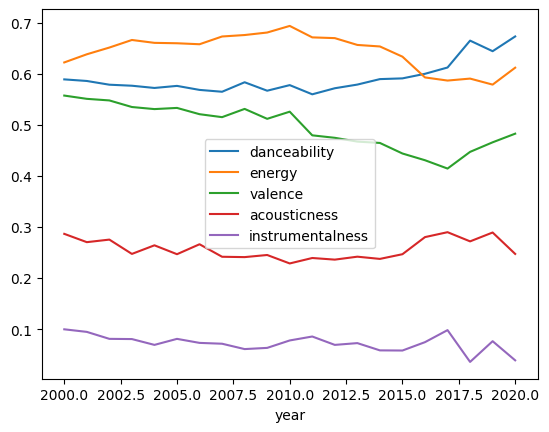

In [30]:
#compare audio features over time (2000-2020)
features = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness']

df.groupby('year')[features].mean().plot()

In [31]:
#compare features of eras and popularity
df.groupby('era')[features].mean()
df.groupby(['era', 'category'])[features].mean()

danceability    energy   valence  acousticness  \
era    category                                                     
blog   mainstream      0.604087  0.691462  0.545610      0.213213   
       niche           0.569780  0.658319  0.520542      0.259787   
modern mainstream      0.633840  0.598555  0.451555      0.274084   
       niche           0.590654  0.639440  0.451956      0.243972   

                   instrumentalness  
era    category                      
blog   mainstream          0.039876  
       niche               0.083993  
modern mainstream          0.065582  
       niche               0.062923

In [32]:
#statistical difference testing

from scipy.stats import ttest_ind, mannwhitneyu

#extract feature array
blog_era_vals = df[df['era'] == 'blog']['energy']
modern_era_vals = df[df['era'] == 'modern']['energy']

#t-testing
t_stat, p_val_t = ttest_ind(blog_era_vals, modern_era_vals, equal_var=False)

#mann-whitney
u_stat, p_val_u = mannwhitneyu(blog_era_vals, modern_era_vals)

print("t-test p-value:", p_val_t)
print("Mann-Whitney p-value:", p_val_u)

t-test p-value: 2.01420748395405e-111
Mann-Whitney p-value: 1.5133312361955777e-153


In [33]:
import numpy as np
import pandas as pd

# features = ['energy', 'valence', 'instrumentalness', 'danceability', 'acousticness']
features = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness']

results = []

def cohens_d(x, y):
    return (np.mean(x) - np.mean(y)) / np.sqrt((np.var(x) + np.var(y)) / 2)


#loop over all features in statistical analysis
for feature in features:
    blog_vals = df[df['era'] == 'blog'][feature]
    modern_vals = df[df['era'] == 'modern'][feature]

    #drop missing values
    blog_vals = blog_vals.dropna()
    modern_vals = modern_vals.dropna()

    t_stat, p_t = ttest_ind(blog_vals, modern_vals, equal_var=False)
    u_stat, p_u = mannwhitneyu(blog_vals, modern_vals)
    d = cohens_d(blog_vals, modern_vals)

    results.append({
        'feature': feature,
        'p_ttest': p_t,
        'p_mannwhitney': p_u,
        'cohens_d': d
    })

results_df = pd.DataFrame(results)
print(results_df)

            feature        p_ttest  p_mannwhitney  cohens_d
0      danceability  2.196524e-138  8.874497e-160 -0.254556
1            energy  2.014207e-111  1.513331e-153  0.225592
2           valence  2.195407e-189  2.466325e-174  0.295830
3      acousticness   4.002094e-04   1.478444e-33 -0.035710
4  instrumentalness   3.932767e-09   6.053536e-77  0.059205


**What These Results Mean**

Statistical testing revealed significant differences across all examined audio features (p < 0.001). However, effect size analysis using Cohen’s d indicates that most differences are small in magnitude. Valence (d = 0.296) and danceability (d = -0.255) exhibit the largest shifts, suggesting modest changes in emotional tone and rhythmic structure between eras. In contrast, instrumentalness (d = 0.059) and acousticness (d = -0.036) show negligible differences, highlighting the importance of distinguishing statistical significance from practical significance in large datasets.

In [34]:
#machine learning model 1 — logistic regression
#ponders the question: “Can we distinguish blog-era vs modern music based on sound alone?”

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

#---------- STEP 1: define features + target ------------------

X = df[features]

#convert eras into numeric labels
# blog era (2000–2012) = 0
# modern era (2013–2020) = 1

df['era_label'] = df['era'].map({
    'blog': 0,
    'modern': 1
})

y = df['era_label']
# y = df['era']

#---------- STEP 2: train/test split ----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#----------- STEP 3: scale the features ------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#----------- STEP 4: train logistic regression -------------------

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
log_model.fit(X_train_scaled, y_train)

#------------ STEP 5: make predictions ---------------------------

y_pred = log_model.predict(X_test_scaled)

#------------- STEP 6: evaluate model + print results ---------------

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5997

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.61      0.66      5200
           1       0.47      0.58      0.52      3132

    accuracy                           0.60      8332
   macro avg       0.59      0.60      0.59      8332
weighted avg       0.62      0.60      0.61      8332


Confusion Matrix:

[[3171 2029]
 [1306 1826]]


In [35]:
#machine learning model 2 – random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.6788

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.85      0.77      5200
           1       0.62      0.39      0.48      3132

    accuracy                           0.68      8332
   macro avg       0.66      0.62      0.62      8332
weighted avg       0.67      0.68      0.66      8332


Confusion Matrix:

[[4438  762]
 [1914 1218]]


            feature  importance
2           valence    0.233213
0      danceability    0.218091
1            energy    0.214808
3      acousticness    0.212304
4  instrumentalness    0.121586


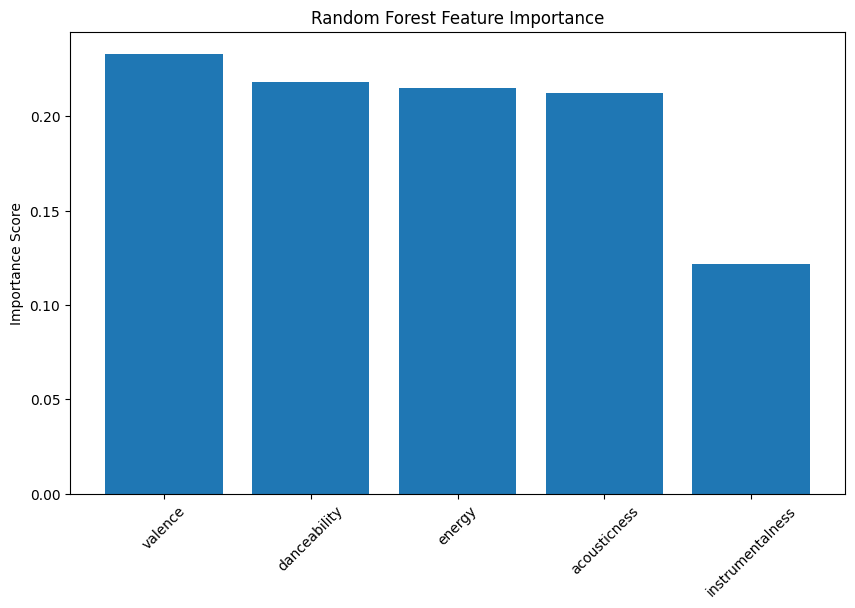

In [36]:
#plotting feature importance

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

print(importance_df)

# Plot feature importance
plt.figure(figsize=(10,6))
plt.bar(
    importance_df['feature'],
    importance_df['importance']
)

plt.xticks(rotation=45)
plt.title('Random Forest Feature Importance')
plt.ylabel('Importance Score')
plt.show()

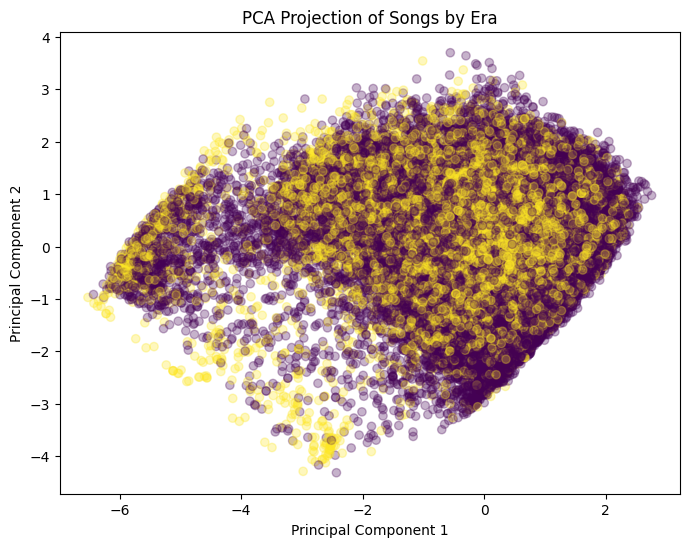

In [37]:
#PCA visualization
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['era_label'],
    alpha=0.3
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Songs by Era')

plt.show()